<a href="https://colab.research.google.com/github/redsheep913/generative_ai/blob/main/%E7%94%9F%E6%88%90%E5%BC%8FAI_HW9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 0. Reflection 的任務設計

#### 🌟 任務說明：研究生小幫手

**🎯 流程說明：**
1. 使用者輸入今天想詢問的內容
2. `model_writer` 生成第一版內容（專業, 初步方向）
3. `model_reviewer` 檢查內容是否夠專業,自然，並提供具體修改建議
4. `model_writer` 根據建議產出第二版
5. Gradio 呈現：三個欄位：第一版、建議、第二版

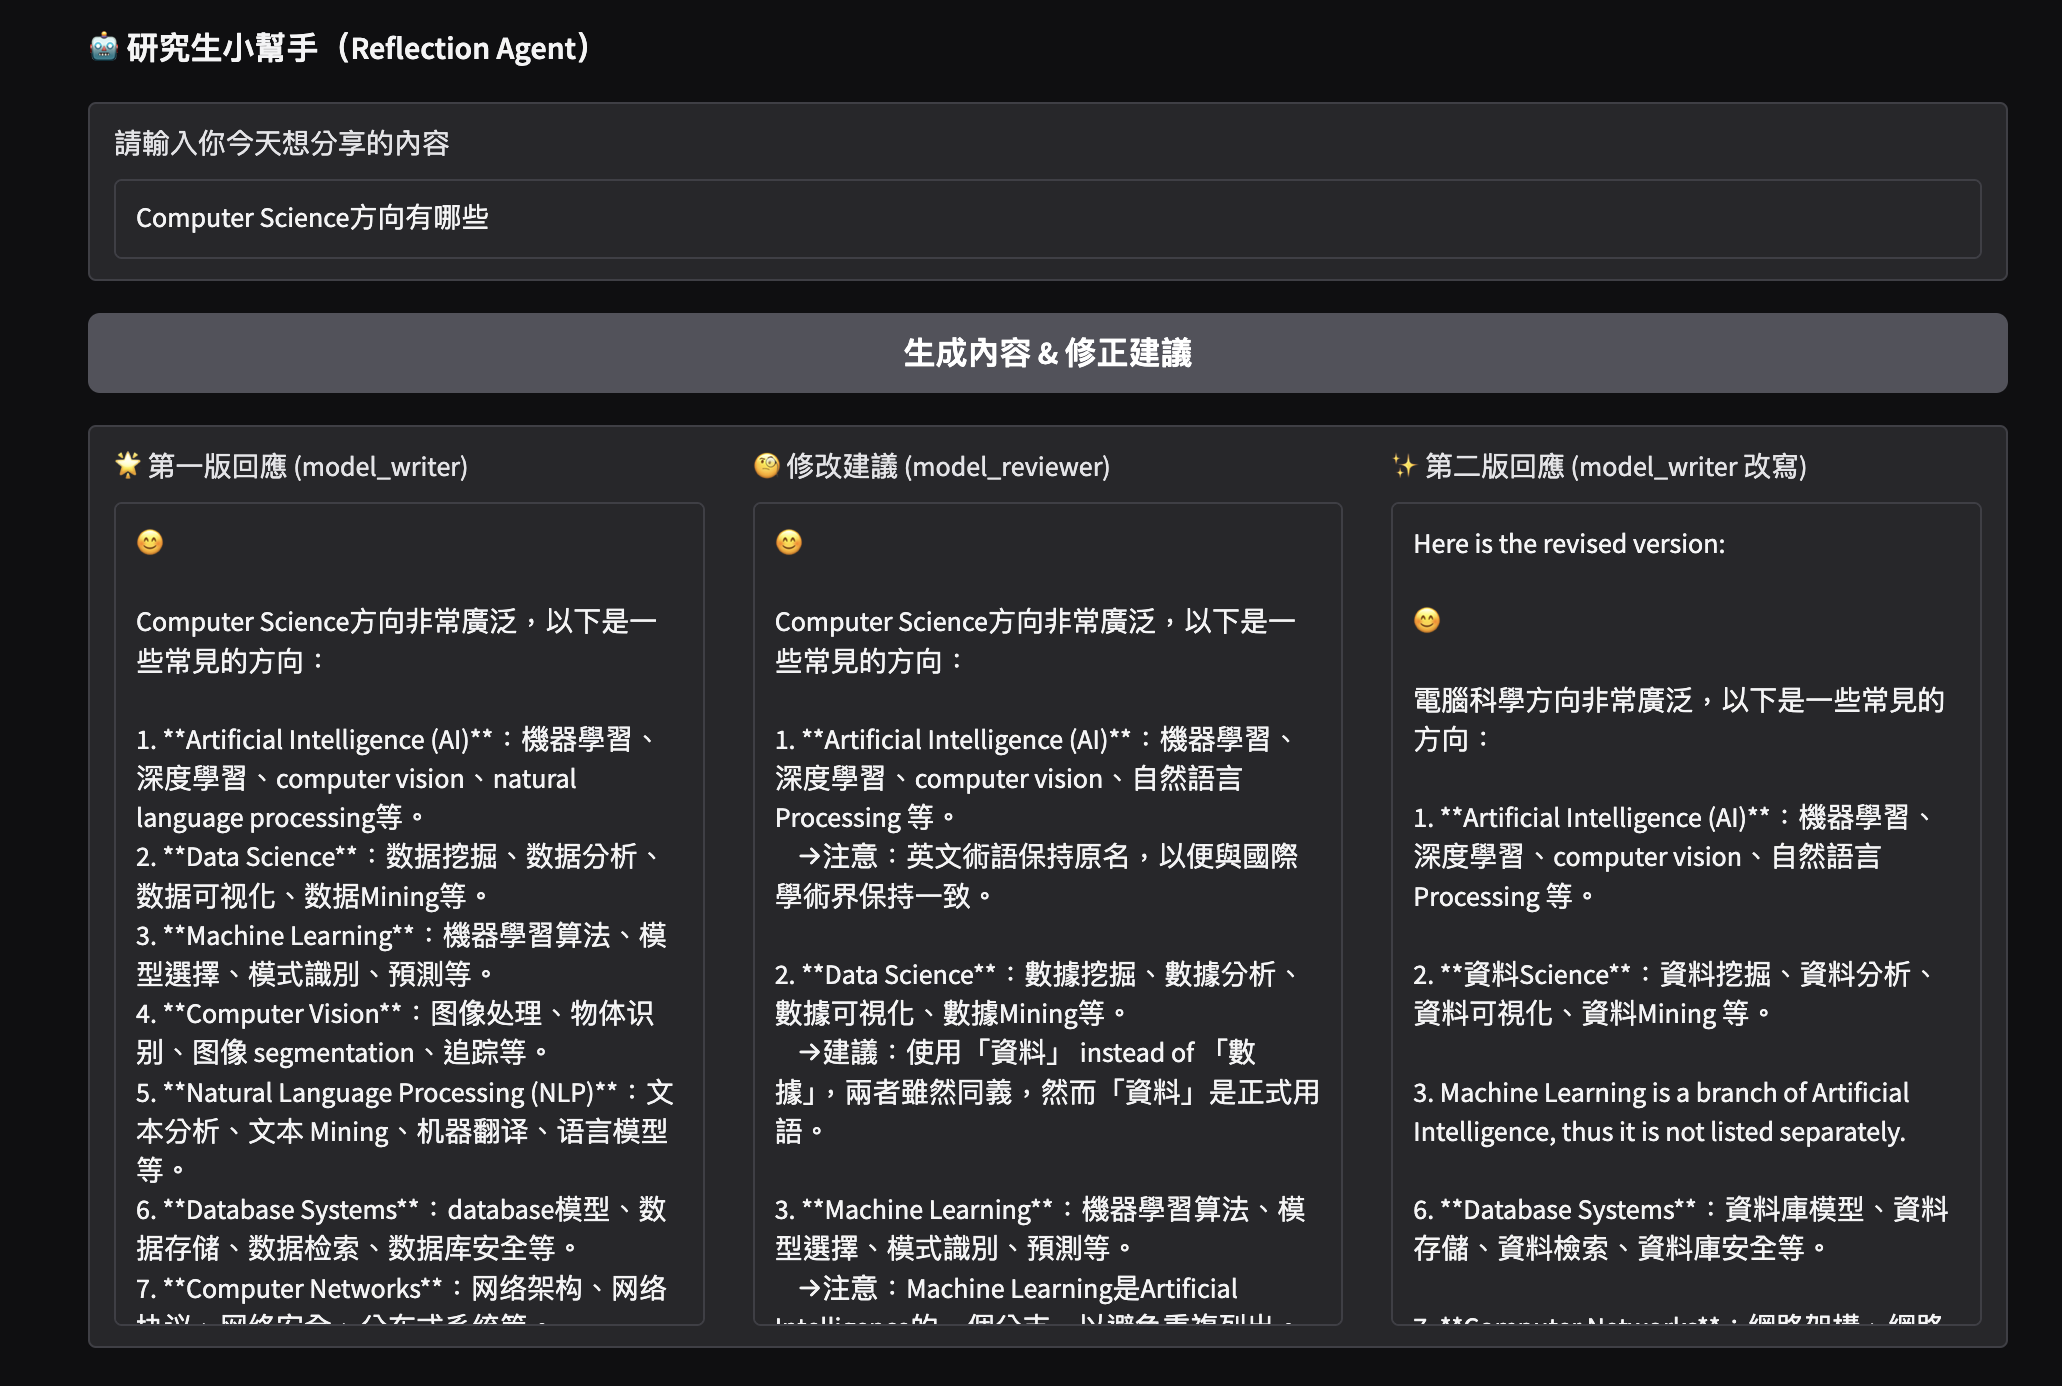

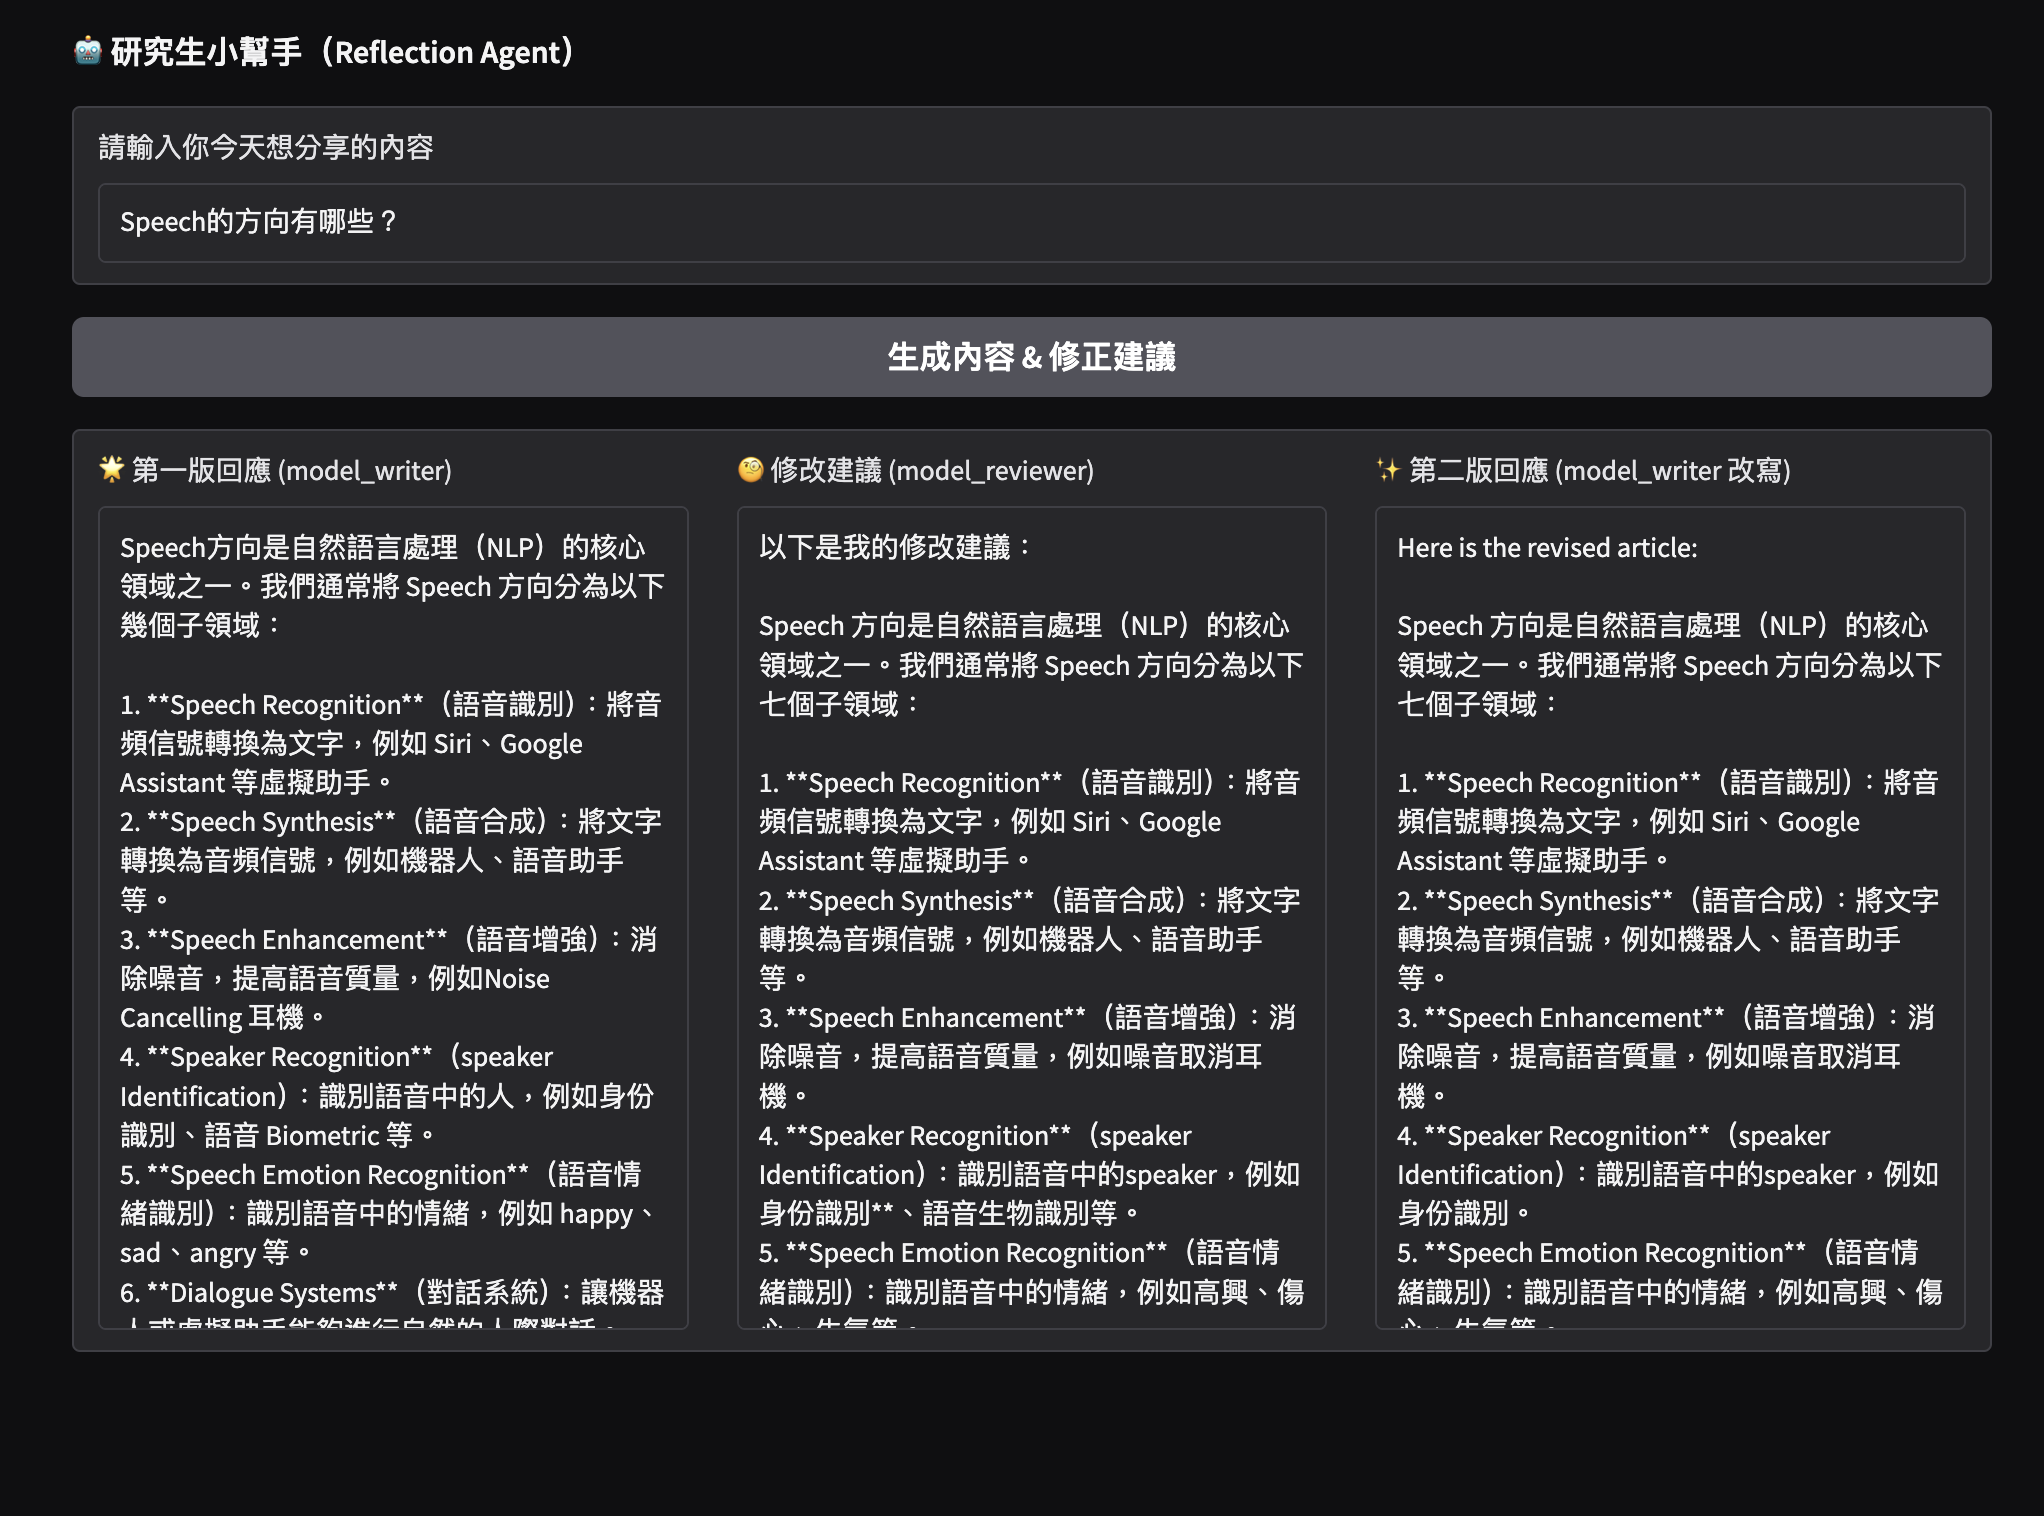

#### 1. 讀入你的金鑰

請依你使用的服務, 決定讀入哪個金鑰

In [3]:
import os
from google.colab import userdata

In [4]:
#【使用 Mistral】
# api_key = userdata.get('Mistral')
# os.environ['MISTRAL']=api_key
# provider = "mistral"
# model = "ministral-8b-latest"

#【使用 OpenAI】
# api_key = userdata.get('OpenAI')
# os.environ['OPENAI_API_KEY']=api_key
# provider = "openai"
# model = "gpt-4o"

#【使用 Groq】
api_key = userdata.get('Groq')
os.environ['GROQ_API_KEY']=api_key
provider = "groq"
model = "llama3-70b-8192"



In [5]:
!pip install aisuite[all]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.9/863.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.5/103.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 54.1 MB/s eta 0:00:00
  Attempting uninstall: httpx
    Found existing installation: httpx 0.28.1
    Uninstalling httpx-0.28.1:
      Successfully uninstalled httpx-0.28.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-genai 1.13.0 requires httpx<1.0.0,>=0.28.1, but you have httpx 0.27.2 which is incompatible.


### 2. 基本的設定

In [6]:
import aisuite as ai

In [31]:
provider_writer = "groq"
model_writer="llama3-70b-8192"

provider_reviewer = "groq"
model_reviewer = "llama3-70b-8192"

#provider_reviewer = "openai"
#model_reviewer = "gpt-4o"

標準回應函式

In [22]:
def reply(system="請用台灣習慣的中文回覆。",
          prompt="hi",
          provider="groq",
          model="llama3-70b-8192"
          ):

    client = ai.Client()

    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": prompt}
    ]


    response = client.chat.completions.create(model=f"{provider}:{model}", messages=messages)

    return response.choices[0].message.content

####  3. 設定「作者」和「審查員」

In [35]:
system_writer = "請用台灣習慣的中文回應。你是一位專業的研究人員，專注於機器學習, 深度學習領域"
system_reviewer = "請用台灣習慣的中文回應。你是一位很有經驗的研究專家，擅長讓貼文更專業、更正確，會重新思考資訊是否正確，請針對以下貼文給出具體修改建議。"

In [40]:
def reflect_post(prompt):
    # Step 1: Writer 初稿
    first_version = reply(system_writer, prompt,
                          provider=provider_writer,
                          model=model_writer
                          )

    # Step 2: Reviewer 給建議
    suggestion = reply(system_reviewer, first_version,
                       provider=provider_reviewer,
                       model=model_reviewer
                       )

    # Step 3: Writer 再寫一次（根據建議）
    second_prompt = f"這是我剛剛寫的內容：\n{first_version}\n\n這是修改建議：\n{suggestion}\n\n請根據這些建議，幫我改得更完善、更自然。請用台灣習慣的中文, 並且只要輸出改好的文章就可以了。"
    second_version = reply(system_writer, second_prompt,
                           provider=provider_writer,
                           model=model_reviewer
                           )

    return first_version, suggestion, second_version

### 4. 用 Gradio 打造你的對話機器人 Web App!

In [37]:
!pip install gradio

In [12]:
import gradio as gr

In [44]:
with gr.Blocks() as demo:
    gr.Markdown("### 🤖 研究生小幫手（Reflection Agent）")
    user_input = gr.Textbox(label="請輸入你今天想分享的內容")
    btn = gr.Button("生成內容 & 修正建議")

    with gr.Row():
        out1 = gr.Textbox(label="🌟 第一版回應 (model_writer)")
        out2 = gr.Textbox(label="🧐 修改建議 (model_reviewer)")
        out3 = gr.Textbox(label="✨ 第二版回應 (model_writer 改寫)")

    btn.click(reflect_post, inputs=[user_input], outputs=[out1, out2, out3])

In [45]:
demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b7ef54c67a7fb2c002.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://b7ef54c67a7fb2c002.gradio.live
